# Main Figure Revision

In [194]:
# preamble

from pathlib import Path
import sys
import warnings
import pickle

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import pyreadr
from IPython.display import display, Markdown
from matplotlib.patches import Circle, Ellipse, FancyArrowPatch, FancyBboxPatch, Rectangle
from scipy.stats import chi2, entropy, ttest_ind
from sklearn.datasets import load_breast_cancer, fetch_openml, load_diabetes
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score, roc_auc_score
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import LabelEncoder, StandardScaler

warnings.filterwarnings("ignore", category=FutureWarning)

repo_root = Path.cwd()
if repo_root.name == "notebooks":
    repo_root = repo_root.parents[1]

CACHE_DIR = repo_root / "data_synthesis" / "notebooks" / "revision_cache"
CACHE_DIR.mkdir(parents=True, exist_ok=True)

pkg_root = repo_root / "data_synthesis"
if str(pkg_root) not in sys.path:
    sys.path.insert(0, str(pkg_root))

from models.bootstrap import sample_bootstrap
from models.cvae import sample_cvae, train_cvae, sample_trained_cvae
from models.gmm import sample_gmm
from models.iid_columnwise import sample_columnwise
from util.config import Config
from rfhack.core.rf_wrapper import RFWrapper

SEED = 42

# Toggle this first when iterating on visual style.
# Use "preview" for quick layout checks and "final" for manuscript runs.
REVISION_RUN_MODE = "final"
RUN_MODE = REVISION_RUN_MODE

RUN_PRESETS = {
    "preview": {
        "CVAE_EPOCHS": 10,
        "AUC_REPEATS": 5,
        "TSTR_REPEATS": 3,
        "ABLATION_REPEATS": 3,
        "NOISE_REPEATS": 2,
        "PROBE_SIGMAS": [0.0, 0.2, 0.5, 1.0],
    },
    "final": {
        "CVAE_EPOCHS": 200,
        "AUC_REPEATS": 50,
        "TSTR_REPEATS": 20,
        "ABLATION_REPEATS": 20,
        "NOISE_REPEATS": 5,
        "PROBE_SIGMAS": [0.0, 0.05, 0.1, 0.2, 0.3, 0.5, 0.75, 1.0, 1.5, 2.0],
    },
}

if RUN_MODE not in RUN_PRESETS:
    raise ValueError(f"RUN_MODE must be one of {list(RUN_PRESETS)}")

_run_cfg = RUN_PRESETS[RUN_MODE]
CVAE_EPOCHS = _run_cfg["CVAE_EPOCHS"]
AUC_REPEATS = _run_cfg["AUC_REPEATS"]
TSTR_REPEATS = _run_cfg["TSTR_REPEATS"]
ABLATION_REPEATS = _run_cfg["ABLATION_REPEATS"]
NOISE_REPEATS = _run_cfg["NOISE_REPEATS"]
PROBE_SIGMAS = _run_cfg["PROBE_SIGMAS"]
NOISE_FRAC = 0.3

# Optional one-off overrides while designing figures. Leave as None to use the selected preset.
OVERRIDE_CVAE_EPOCHS = None
OVERRIDE_AUC_REPEATS = None
OVERRIDE_TSTR_REPEATS = None
OVERRIDE_ABLATION_REPEATS = None
OVERRIDE_NOISE_REPEATS = None
OVERRIDE_PROBE_SIGMAS = None

CVAE_EPOCHS = OVERRIDE_CVAE_EPOCHS or CVAE_EPOCHS
AUC_REPEATS = OVERRIDE_AUC_REPEATS or AUC_REPEATS
TSTR_REPEATS = OVERRIDE_TSTR_REPEATS or TSTR_REPEATS
ABLATION_REPEATS = OVERRIDE_ABLATION_REPEATS or ABLATION_REPEATS
NOISE_REPEATS = OVERRIDE_NOISE_REPEATS or NOISE_REPEATS
PROBE_SIGMAS = OVERRIDE_PROBE_SIGMAS or PROBE_SIGMAS

DATASET_ORDER = ["HIV", "Breast Cancer", "Diabetes"]
DATASET_COLORS = {"HIV": "#EA5C1F", "Breast Cancer": "#1DB100", "Diabetes": "#0076BA"}
DATASET_MARKERS = {"HIV": "^", "Breast Cancer": "o", "Diabetes": "s"}
METHOD_ORDER = ["Bootstrap", "Column-wise", "GMM", "CVAE"]
METHOD_COLORS = {"Bootstrap": "#6A5ACD", "Column-wise": "#CC79A7", "GMM": "#009E73", "CVAE": "#D55E00"}
METHOD_PASTELS = {"Bootstrap": "#C7C2F4", "Column-wise": "#E8B4D2", "GMM": "#A8DEC9", "CVAE": "#F2B49B"}
REAL_BLUE = "#9ECAE1"
SYN_RED = "#F4A6A6"
REAL_GREY = "#333434"
CVAE_ORANGE = "#D55E00"
LABEL_RED = "#C62828"
NEUTRAL = "#333434"

METHODS = {
    "Bootstrap": sample_bootstrap,
    "Column-wise": sample_columnwise,
    "GMM": sample_gmm,
    "CVAE": sample_cvae,
}

mpl.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "savefig.facecolor": "white",
    "font.family": "DejaVu Sans",
    "font.size": 13,
    "axes.titlesize": 15,
    "axes.labelsize": 14,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 11,
    "legend.title_fontsize": 11,
    "axes.linewidth": 2.2,
    "xtick.major.width": 1.8,
    "ytick.major.width": 1.8,
    "xtick.major.size": 6,
    "ytick.major.size": 6,
    "lines.linewidth": 3.0,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "svg.fonttype": "none",
})

print(f"Repository root: {repo_root}")
print(f"Run mode: {RUN_MODE} | CVAE_EPOCHS={CVAE_EPOCHS}, AUC_REPEATS={AUC_REPEATS}, TSTR_REPEATS={TSTR_REPEATS}, ABLATION_REPEATS={ABLATION_REPEATS}, NOISE_REPEATS={NOISE_REPEATS}")


def _to_numpy_X(X):
    return np.asarray(X.values if hasattr(X, "values") else X, dtype=np.float32)


def _to_numpy_y(y):
    y = np.asarray(y.values if hasattr(y, "values") else y).reshape(-1)
    if y.dtype.kind in {"i", "u", "b"}:
        return y.astype(int)
    return LabelEncoder().fit_transform(y).astype(int)


def load_hiv():
    rdata_path = repo_root / "data_synthesis" / "data" / "allSyntheticData.RData"
    obj = pyreadr.read_r(str(rdata_path))
    x_df = obj["x"]
    y_df = obj["y"]
    return {
        "dataset": "HIV",
        "X": _to_numpy_X(x_df),
        "y": _to_numpy_y(y_df),
        "feature_names": list(x_df.columns),
    }


def load_breast():
    raw = load_breast_cancer()
    return {
        "dataset": "Breast Cancer",
        "X": _to_numpy_X(raw.data),
        "y": _to_numpy_y(raw.target),
        "feature_names": list(raw.feature_names),
    }


def load_diabetes_dataset():
    try:
        raw = fetch_openml("diabetes", version=1, as_frame=False)
        return {
            "dataset": "Diabetes",
            "X": _to_numpy_X(raw.data),
            "y": _to_numpy_y(raw.target),
            "feature_names": list(raw.feature_names),
        }
    except Exception as exc:
        print(f"[fallback] OpenML diabetes unavailable ({exc}); using sklearn diabetes binarized at median target.")
        raw = load_diabetes()
        y = (raw.target >= np.median(raw.target)).astype(int)
        return {
            "dataset": "Diabetes",
            "X": _to_numpy_X(raw.data),
            "y": y,
            "feature_names": list(raw.feature_names),
        }


LOADERS = {"HIV": load_hiv, "Breast Cancer": load_breast, "Diabetes": load_diabetes_dataset}


def load_datasets():
    out = {}
    for name in DATASET_ORDER:
        out[name] = LOADERS[name]()
    return out


def class_counts(y):
    y = np.asarray(y).astype(int)
    return int(np.sum(y == 0)), int(np.sum(y == 1))


def sample_synthetic(dataset, data, method, seed=SEED, cvae_epochs=CVAE_EPOCHS):
    X = np.asarray(data["X"], dtype=np.float32)
    y = np.asarray(data["y"], dtype=int)
    n0, n1 = class_counts(y)
    if method == "CVAE":
        cfg = Config(seed=seed, epochs=cvae_epochs)
        return sample_cvae(X, y, n0, n1, seed=seed, cfg=cfg)
    return METHODS[method](X, y, n0, n1, seed=seed)


def standardize_pair(X_real, X_syn):
    scaler = StandardScaler()
    Xr = scaler.fit_transform(np.asarray(X_real, dtype=np.float64))
    Xs = scaler.transform(np.asarray(X_syn, dtype=np.float64))
    return Xr, Xs


def clean_axis(ax, grid_axis=None):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.tick_params(direction="out")
    if grid_axis:
        ax.grid(axis=grid_axis, color="#D9D9D9", linewidth=0.8, alpha=0.45)
    else:
        ax.grid(False)


def add_panel_label(ax, label, color=NEUTRAL):
    ax.text(-0.12, 1.08, label, transform=ax.transAxes, ha="left", va="top", fontsize=18, weight="bold", color=color)


def add_confidence_ellipse(ax, xy, color, linestyle="-", linewidth=2.0):
    xy = np.asarray(xy, dtype=float)
    if xy.shape[0] < 3:
        return
    cov = np.cov(xy, rowvar=False)
    vals, vecs = np.linalg.eigh(cov)
    vals = np.maximum(vals, 0)
    order = vals.argsort()[::-1]
    vals, vecs = vals[order], vecs[:, order]
    angle = np.degrees(np.arctan2(vecs[1, 0], vecs[0, 0]))
    scale = np.sqrt(chi2.ppf(0.95, df=2))
    width, height = 2 * scale * np.sqrt(vals)
    ax.add_patch(Ellipse(xy.mean(axis=0), width=width, height=height, angle=angle,
                         facecolor="none", edgecolor=color, linewidth=linewidth, linestyle=linestyle))


datasets = load_datasets()
summary = pd.DataFrame([
    {
        "dataset": name,
        "samples": len(data["y"]),
        "features": np.asarray(data["X"]).shape[1],
        "class_0": int((np.asarray(data["y"]) == 0).sum()),
        "class_1": int((np.asarray(data["y"]) == 1).sum()),
    }
    for name, data in datasets.items()
])
summary


def plot_figure2_cvae_pca(datasets, seed=SEED, cvae_epochs=CVAE_EPOCHS):
    fig, axes = plt.subplots(1, 3, figsize=(13.6, 3.85))
    for ax, ds, panel in zip(axes, DATASET_ORDER, ["A", "B", "C"]):
        data = datasets[ds]
        X_real = np.asarray(data["X"], dtype=np.float32)
        X_syn, _ = sample_synthetic(ds, data, "CVAE", seed=seed, cvae_epochs=cvae_epochs)
        Xr, Xs = standardize_pair(X_real, X_syn)
        pca = PCA(n_components=2, random_state=seed).fit(Xr)
        Zr = pca.transform(Xr)
        Zs = pca.transform(Xs)
        rng = np.random.default_rng(seed)
        Zs_plot = Zs[rng.choice(len(Zs), size=700, replace=False)] if len(Zs) > 700 else Zs

        point_size = 10
        real_color = "#8A8A8A"
        syn_color = DATASET_COLORS[ds]
        ax.scatter(Zr[:, 0], Zr[:, 1], s=point_size, marker="o", facecolors="none", alpha=0.62,
                   edgecolors=real_color, linewidths=0.65, label="Real data")
        ax.scatter(Zs_plot[:, 0], Zs_plot[:, 1], s=point_size, marker="o", color=syn_color, alpha=0.78,
                   edgecolors="none", label="CVAE synthetic data")
        add_confidence_ellipse(ax, Zr, real_color, linestyle="-", linewidth=2.2)
        add_confidence_ellipse(ax, Zs, syn_color, linestyle="-", linewidth=2.4)

        all_z = np.vstack([Zr, Zs_plot])
        x_min, x_max = np.nanmin(all_z[:, 0]), np.nanmax(all_z[:, 0])
        y_min, y_max = np.nanmin(all_z[:, 1]), np.nanmax(all_z[:, 1])
        x_pad = max((x_max - x_min) * 0.24, 1e-6)
        y_pad = max((y_max - y_min) * 0.24, 1e-6)
        ax.set_xlim(x_min - x_pad, x_max + x_pad)
        ax.set_ylim(y_min - y_pad, y_max + y_pad)

        ev = pca.explained_variance_ratio_
        ax.set_title(ds, color=DATASET_COLORS[ds], weight="bold", pad=8, fontsize=12.0)
        ax.set_xlabel(f"PC1 ({ev[0] * 100:.1f}%)", color="black", fontsize=10.0)
        ax.set_ylabel(f"PC2 ({ev[1] * 100:.1f}%)", color="black", fontsize=10.0, labelpad=6)
        ax.text(0.045, 0.055, f"n = {len(data['y'])}, p = {X_real.shape[1]}", transform=ax.transAxes,
                color=DATASET_COLORS[ds], fontsize=9.0, weight="bold", ha="left", va="bottom")
        ax.legend(loc="upper left", frameon=True, facecolor="white", edgecolor="#BDBDBD",
                  framealpha=0.92, fontsize=7.8, handlelength=1.2, borderpad=0.35,
                  labelspacing=0.25, handletextpad=0.35)

        ax.tick_params(axis="both", colors="black", direction="out", width=1.2, length=4, labelsize=8.8)
        ax.grid(False)
        for spine in ax.spines.values():
            spine.set_visible(True)
            spine.set_edgecolor("black")
            spine.set_linewidth(1.25)
        add_panel_label(ax, panel)

    fig.subplots_adjust(left=0.070, right=0.985, top=0.84, bottom=0.20, wspace=0.25)

    for left_ax, right_ax in zip(axes[:-1], axes[1:]):
        left_box = left_ax.get_position()
        right_box = right_ax.get_position()
        x_sep = (left_box.x1 + right_box.x0) / 2
        fig.add_artist(mpl.lines.Line2D([x_sep, x_sep], [0.20, 0.80], transform=fig.transFigure,
                                        color="#D8D8D8", linewidth=0.8, alpha=0.75))
    plt.show()


def one_run_origin_auc(X_real, y_real, X_syn, y_syn, seed):
    """Class-balanced real-vs-synthetic RF probe for one random split."""
    rng = np.random.default_rng(seed)
    X_real = np.asarray(X_real, dtype=np.float64)
    X_syn = np.asarray(X_syn, dtype=np.float64)
    y_real = np.asarray(y_real, dtype=int)
    y_syn = np.asarray(y_syn, dtype=int)
    real_neg, real_pos = np.where(y_real == 0)[0], np.where(y_real == 1)[0]
    syn_neg, syn_pos = np.where(y_syn == 0)[0], np.where(y_syn == 1)[0]
    n_neg = min(len(real_neg), len(syn_neg))
    n_pos = min(len(real_pos), len(syn_pos))
    real_idx = np.r_[rng.choice(real_neg, n_neg, replace=False), rng.choice(real_pos, n_pos, replace=False)]
    syn_idx = np.r_[rng.choice(syn_neg, n_neg, replace=False), rng.choice(syn_pos, n_pos, replace=False)]
    Xr, Xs = standardize_pair(X_real[real_idx], X_syn[syn_idx])
    X = np.vstack([Xr, Xs])
    origin = np.r_[np.zeros(len(Xr), dtype=int), np.ones(len(Xs), dtype=int)]
    X_train, X_test, y_train, y_test = train_test_split(X, origin, test_size=0.25, stratify=origin, random_state=seed)
    rf = RandomForestClassifier(n_estimators=500, random_state=seed, class_weight="balanced", n_jobs=-1)
    rf.fit(X_train, y_train)
    auc = roc_auc_score(y_test, rf.predict_proba(X_test)[:, 1])
    return float(max(auc, 1.0 - auc))


def compute_auc_run_table(datasets, seed=SEED, repeats=AUC_REPEATS, cvae_epochs=CVAE_EPOCHS):
    rows = []
    for ds in DATASET_ORDER:
        data = datasets[ds]
        X_real = np.asarray(data["X"], dtype=np.float32)
        y_real = np.asarray(data["y"], dtype=int)
        for method in METHOD_ORDER:
            print(f"[AUC runs] {ds} - {method}")
            X_syn, y_syn = sample_synthetic(ds, data, method, seed=seed, cvae_epochs=cvae_epochs)
            for r in range(repeats):
                auc = one_run_origin_auc(X_real, y_real, X_syn, y_syn, seed=seed + 1000*r + 17*METHOD_ORDER.index(method))
                rows.append({"dataset": ds, "method": method, "run": r, "separability_auc": auc})
    return pd.DataFrame(rows)


def mean_kld_by_feature(X_real, X_syn, bins=30):
    X_real = np.asarray(X_real, dtype=float)
    X_syn = np.asarray(X_syn, dtype=float)
    vals = []
    for j in range(X_real.shape[1]):
        lo = float(min(np.nanmin(X_real[:, j]), np.nanmin(X_syn[:, j])))
        hi = float(max(np.nanmax(X_real[:, j]), np.nanmax(X_syn[:, j])))
        if not np.isfinite(lo + hi) or hi <= lo:
            vals.append(0.0)
            continue
        edges = np.linspace(lo, hi, bins + 1)
        p, _ = np.histogram(X_real[:, j], bins=edges, density=True)
        q, _ = np.histogram(X_syn[:, j], bins=edges, density=True)
        p = p + 1e-10
        q = q + 1e-10
        vals.append(float(entropy(p / p.sum(), q / q.sum())))
    return np.asarray(vals, dtype=float)


def nn_distance_mean(X_real, X_syn):
    Xr, Xs = standardize_pair(X_real, X_syn)
    nn = NearestNeighbors(n_neighbors=1).fit(Xr)
    dists, _ = nn.kneighbors(Xs)
    return float(np.mean(dists))


def tstr_values(X_real, y_real, X_syn, y_syn, seed=SEED, repeats=TSTR_REPEATS):
    Xr, Xs = standardize_pair(X_real, X_syn)
    y_real = np.asarray(y_real, dtype=int)
    y_syn = np.asarray(y_syn, dtype=int)
    n_splits = max(2, min(5, int((y_real == 0).sum()), int((y_real == 1).sum())))
    out = []
    trtr = []
    for r in range(repeats):
        run_seed = seed + r * 1009
        clf = RandomForestClassifier(n_estimators=300, random_state=run_seed, class_weight="balanced", n_jobs=-1)
        clf.fit(Xs, y_syn)
        out.append(float(f1_score(y_real, clf.predict(Xr), zero_division=0)))
        fold_scores = []
        cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=run_seed)
        for train_idx, test_idx in cv.split(Xr, y_real):
            rf = RandomForestClassifier(n_estimators=300, random_state=run_seed, class_weight="balanced", n_jobs=-1)
            rf.fit(Xr[train_idx], y_real[train_idx])
            fold_scores.append(float(f1_score(y_real[test_idx], rf.predict(Xr[test_idx]), zero_division=0)))
        trtr.append(float(np.mean(fold_scores)))
    return np.asarray(out), np.asarray(trtr)


def build_metric_table(datasets, auc_runs, seed=SEED, cvae_epochs=CVAE_EPOCHS):
    rows = []
    for ds in DATASET_ORDER:
        data = datasets[ds]
        X_real = np.asarray(data["X"], dtype=np.float32)
        y_real = np.asarray(data["y"], dtype=int)
        for method in METHOD_ORDER:
            print(f"[metric table] {ds} - {method}")
            X_syn, y_syn = sample_synthetic(ds, data, method, seed=seed, cvae_epochs=cvae_epochs)
            tstr, trtr = tstr_values(X_real, y_real, X_syn, y_syn, seed=seed)
            gap = np.abs(trtr - tstr)
            auc_vals = auc_runs[(auc_runs["dataset"] == ds) & (auc_runs["method"] == method)]["separability_auc"].to_numpy()
            klds = mean_kld_by_feature(X_real, X_syn)
            rows.append({
                "dataset": ds,
                "method": method,
                "rf_auc_mean": float(np.mean(auc_vals)),
                "rf_auc_sd": float(np.std(auc_vals)),
                "rf_auc_values": auc_vals.tolist(),
                "tstr_f1_mean": float(np.mean(tstr)),
                "tstr_f1_sd": float(np.std(tstr)),
                "tstr_f1_values": tstr.tolist(),
                "utility_gap_abs_mean": float(np.mean(gap)),
                "utility_gap_abs_sd": float(np.std(gap)),
                "utility_gap_abs_values": gap.tolist(),
                "mean_feature_kld": float(np.mean(klds)),
                "nn_distance_mean": nn_distance_mean(X_real, X_syn),
            })
    return pd.DataFrame(rows)


def format_mean_sd(mean, sd):
    return f"{mean:.2f} +/- {sd:.2f}"


def plot_metric_table_image(metric_table):
    table_df = metric_table.copy()
    table_df["RF separability"] = [format_mean_sd(m, s) for m, s in zip(table_df["rf_auc_mean"], table_df["rf_auc_sd"])]
    table_df["TSTR F1"] = [format_mean_sd(m, s) for m, s in zip(table_df["tstr_f1_mean"], table_df["tstr_f1_sd"])]
    table_df["|TRTR - TSTR|"] = [format_mean_sd(m, s) for m, s in zip(table_df["utility_gap_abs_mean"], table_df["utility_gap_abs_sd"])]
    table_df["Mean KLD"] = table_df["mean_feature_kld"].map(lambda v: f"{v:.2f}")
    table_df["NN distance"] = table_df["nn_distance_mean"].map(lambda v: f"{v:.2f}")
    table_df = table_df[["dataset", "method", "RF separability", "TSTR F1", "|TRTR - TSTR|", "Mean KLD", "NN distance"]]
    table_df.columns = ["Dataset", "Generator", "RF separability", "TSTR F1", "|TRTR - TSTR|", "Mean KLD", "NN distance"]

    fig, ax = plt.subplots(figsize=(14.8, 5.1))
    ax.axis("off")
    tbl = ax.table(cellText=table_df.values, colLabels=table_df.columns, loc="center", cellLoc="center", colLoc="center")
    tbl.auto_set_font_size(False)
    tbl.set_fontsize(10.0)
    tbl.scale(1.0, 1.48)
    for (r, c), cell in tbl.get_celld().items():
        cell.set_edgecolor("white")
        if r == 0:
            cell.set_facecolor(NEUTRAL)
            cell.set_text_props(color="white", weight="bold")
        else:
            ds = table_df.iloc[r-1]["Dataset"]
            cell.set_facecolor("#F7F7F7" if r % 2 else "#FFFFFF")
            if c == 0:
                cell.set_text_props(color=DATASET_COLORS.get(ds, NEUTRAL), weight="bold")
            if c == 1:
                method = table_df.iloc[r-1]["Generator"]
                cell.set_text_props(color=METHOD_COLORS.get(method, NEUTRAL), weight="bold")
    ax.set_title("Synthetic data metric summary", loc="left", fontsize=16, weight="bold", pad=10)
    plt.show()


def _metric_values(row, value_col, mean_col):
    vals = row.get(value_col, None)
    if isinstance(vals, (list, tuple, np.ndarray)) and len(vals) > 0:
        return np.asarray(vals, dtype=float)
    return np.asarray([float(row[mean_col])], dtype=float)


def _draw_grouped_violin_panel(ax, metric_table, value_col, mean_col, sd_col, ylabel, panel, ylim=None):
    x = np.arange(len(METHOD_ORDER))
    offsets = np.linspace(-0.27, 0.27, len(DATASET_ORDER))
    width = 0.20
    legend_handles = []

    for i, method in enumerate(METHOD_ORDER):
        if i % 2 == 0:
            ax.axvspan(i - 0.48, i + 0.48, color="#F3F3F3", zorder=0)
        if i > 0:
            ax.axvline(i - 0.5, color="#D8D8D8", linewidth=0.9, zorder=0)

    for offset, ds in zip(offsets, DATASET_ORDER):
        sub = metric_table[metric_table["dataset"] == ds].set_index("method").reindex(METHOD_ORDER)
        positions = x + offset
        values = [_metric_values(row, value_col, mean_col) for _, row in sub.iterrows()]
        violins = ax.violinplot(values, positions=positions, widths=width, showmeans=False, showmedians=False, showextrema=False)
        for body in violins["bodies"]:
            body.set_facecolor(DATASET_COLORS[ds])
            body.set_edgecolor(DATASET_COLORS[ds])
            body.set_alpha(0.28)
            body.set_linewidth(1.4)
            body.set_zorder(2)
        for pos, vals in zip(positions, values):
            jitter = np.linspace(-0.030, 0.030, len(vals)) if len(vals) > 1 else np.array([0.0])
            ax.scatter(np.full(len(vals), pos) + jitter, vals, s=14, color=DATASET_COLORS[ds], alpha=0.50,
                       edgecolors="white", linewidths=0.25, zorder=3)
        means = sub[mean_col].to_numpy(dtype=float)
        sds = sub[sd_col].to_numpy(dtype=float)
        handle = ax.errorbar(positions, means, yerr=sds, color=DATASET_COLORS[ds], marker=DATASET_MARKERS[ds],
                             linestyle="none", markersize=8.2, elinewidth=2.2, capsize=5.0, capthick=2.0,
                             markeredgecolor="white", markeredgewidth=0.6, label=ds, zorder=4)
        legend_handles.append(handle)
    ax.set_xticks(x)
    ax.set_xticklabels(METHOD_ORDER, rotation=25, ha="right")
    ax.set_xlabel("Synthetic generator")
    ax.set_ylabel(ylabel)
    if ylim:
        ax.set_ylim(*ylim)
    if mean_col == "rf_auc_mean":
        ax.axhline(0.5, color="#777777", linestyle="--", linewidth=1.6)
    if mean_col == "utility_gap_abs_mean":
        ax.axhline(0, color="#777777", linestyle="--", linewidth=1.6)
        ax.text(0.96, 0.92, "Smaller is better", ha="right", va="top", transform=ax.transAxes, fontsize=10.0)
    ax.set_title(ylabel, loc="left", weight="bold")
    clean_axis(ax, grid_axis="y")
    for spine in ["left", "bottom"]:
        ax.spines[spine].set_linewidth(2.2)
    ax.tick_params(width=1.8, length=6)
    add_panel_label(ax, panel)
    return legend_handles

def plot_figure3_metric_panels(metric_table):
    fig, axes = plt.subplots(1, 3, figsize=(16.5, 5.4), constrained_layout=False)
    panel_specs = [
        ("rf_auc_values", "rf_auc_mean", "rf_auc_sd", "Discriminator AUC", "A", (0.45, 1.03)),
        ("tstr_f1_values", "tstr_f1_mean", "tstr_f1_sd", "TSTR F1", "B", None),
        ("utility_gap_abs_values", "utility_gap_abs_mean", "utility_gap_abs_sd", "|TRTR - TSTR|", "C", None),
    ]
    legend_handles = None
    for ax, spec in zip(axes, panel_specs):
        handles = _draw_grouped_violin_panel(ax, metric_table, *spec)
        if legend_handles is None:
            legend_handles = handles
    fig.legend(legend_handles, DATASET_ORDER, loc="upper left", bbox_to_anchor=(0.075, 0.985), ncol=3,
               frameon=True, facecolor="white", edgecolor="black", framealpha=1.0)
    fig.subplots_adjust(left=0.07, right=0.99, top=0.84, bottom=0.23, wspace=0.30)
    plt.show()


def feature_group(name):
    lower = str(name).lower()
    if "igg" in lower and "saliva" in lower:
        return "saliva IgG"
    if "iga" in lower:
        return "saliva IgA"
    if "igg" in lower and ("blood" in lower or "serum" in lower):
        return "serum IgG"
    if "ifng" in lower or "il2" in lower or "dual" in lower:
        return "cytokines"
    if "ace2" in lower or "neut" in lower or "neutral" in lower or "rbd" in lower:
        return "neutralization/ACE2"
    return "other"


FEATURE_GROUP_COLORS = {
    "serum IgG": "#8C564B",
    "saliva IgG": "#D62728",
    "saliva IgA": "#4C78A8",
    "cytokines": "#F2B447",
    "neutralization/ACE2": "#8DBF56",
    "other": "#9E9E9E",
}

PASTEL_CORR_CMAP = mpl.colors.LinearSegmentedColormap.from_list(
    "pastel_corr", ["#8FB7D6", "#F7F7F2", "#D9A067"], N=256
)
ABS_CORR_CMAP = mpl.colors.LinearSegmentedColormap.from_list(
    "pastel_abs_corr", ["#FBFAF7", "#CFE7DF", "#71B6A4", "#2F7F75"], N=256
)


def target_rf_importance(X, y, seed=SEED):
    Xs = StandardScaler().fit_transform(np.asarray(X, dtype=float))
    rf = RandomForestClassifier(n_estimators=800, random_state=seed, class_weight="balanced", n_jobs=-1)
    rf.fit(Xs, np.asarray(y, dtype=int))
    return rf.feature_importances_


def corr_matrix(X):
    C = np.corrcoef(np.asarray(X, dtype=float), rowvar=False)
    C = np.nan_to_num(C, nan=0.0, posinf=0.0, neginf=0.0)
    np.fill_diagonal(C, 1.0)
    return C


def upper_triangle_values(C):
    idx = np.triu_indices_from(C, k=1)
    return C[idx]


def corr_preservation_summary(real_corr, syn_corr):
    x = upper_triangle_values(real_corr)
    y = upper_triangle_values(syn_corr)
    r = float(np.corrcoef(x, y)[0, 1]) if len(x) > 2 and np.std(x) > 0 and np.std(y) > 0 else np.nan
    mae = float(np.mean(np.abs(x - y)))
    return x, y, r, mae


def color_feature_ticklabels(ax, top_features):
    top_features = set(top_features)
    for label in ax.get_yticklabels():
        txt = label.get_text()
        if txt in top_features:
            label.set_color(FEATURE_GROUP_COLORS.get(feature_group(txt), NEUTRAL))
            label.set_fontweight("bold")
            label.set_alpha(1.0)
        else:
            label.set_color("#777777")
            label.set_alpha(0.38)


def short_feature_name(name, max_len=18):
    name = str(name).replace("_", " ")
    return name if len(name) <= max_len else name[:max_len - 1] + "..."


def draw_corr_heatmap(ax, fig, matrix, ordered_features, title, show_y=True, top_features=None):
    im = ax.imshow(matrix, aspect="auto", cmap=PASTEL_CORR_CMAP, vmin=-1, vmax=1)
    ax.set_title(title, loc="left", weight="bold", fontsize=12.8)
    ax.set_xticks([])
    if show_y:
        ax.set_yticks(np.arange(len(ordered_features)))
        ax.set_yticklabels(ordered_features, fontsize=5.8)
        color_feature_ticklabels(ax, top_features or [])
    else:
        ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_linewidth(1.5)
        spine.set_color("#444444")
    cbar = fig.colorbar(im, ax=ax, fraction=0.035, pad=0.015)
    cbar.ax.tick_params(labelsize=8.5, width=1.2, length=3)
    cbar.outline.set_linewidth(1.0)
    return im


def draw_abs_corr_heatmap(ax, fig, matrix, ordered_features, title, show_y=False):
    vmax = max(0.15, float(np.nanpercentile(matrix, 98)))
    im = ax.imshow(matrix, aspect="auto", cmap=ABS_CORR_CMAP, vmin=0, vmax=min(vmax, 1.0))
    ax.set_title(title, loc="left", weight="bold", fontsize=12.8)
    ax.set_xticks([])
    if show_y:
        ax.set_yticks(np.arange(len(ordered_features)))
        ax.set_yticklabels(ordered_features, fontsize=5.8)
    else:
        ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_linewidth(1.5)
        spine.set_color("#444444")
    cbar = fig.colorbar(im, ax=ax, fraction=0.035, pad=0.015)
    cbar.ax.tick_params(labelsize=8.5, width=1.2, length=3)
    cbar.outline.set_linewidth(1.0)
    cbar.set_label("absolute difference", fontsize=9.0)
    return im


def plot_marginal_violin_strip(ax, X_real, X_syn, feature_names, order_idx, representative_method, top_n=10):
    top_idx = list(order_idx[:min(top_n, len(order_idx))])
    Xr_z, Xs_z = standardize_pair(X_real, X_syn)
    positions = np.arange(len(top_idx), dtype=float)
    real_color = "#D5D7DA"
    syn_color = METHOD_COLORS.get(representative_method, "#009E73")

    for pos, feat_idx in zip(positions, top_idx):
        group_color = FEATURE_GROUP_COLORS.get(feature_group(feature_names[feat_idx]), "#9E9E9E")
        vp_real = ax.violinplot([Xr_z[:, feat_idx]], positions=[pos - 0.17], widths=0.28,
                                showmeans=False, showmedians=True, showextrema=False)
        vp_syn = ax.violinplot([Xs_z[:, feat_idx]], positions=[pos + 0.17], widths=0.28,
                               showmeans=False, showmedians=True, showextrema=False)
        for body in vp_real["bodies"]:
            body.set_facecolor(real_color)
            body.set_edgecolor("#5E5E5E")
            body.set_alpha(0.92)
            body.set_linewidth(1.0)
        for body in vp_syn["bodies"]:
            body.set_facecolor(syn_color)
            body.set_edgecolor(group_color)
            body.set_alpha(0.72)
            body.set_linewidth(1.2)
        for key in ["cmedians"]:
            vp_real[key].set_color("#333333")
            vp_real[key].set_linewidth(1.2)
            vp_syn[key].set_color("#333333")
            vp_syn[key].set_linewidth(1.2)

    labels = [short_feature_name(feature_names[i], 16) for i in top_idx]
    ax.set_xticks(positions)
    ax.set_xticklabels(labels, rotation=55, ha="right", fontsize=8.2)
    for tick, feat_idx in zip(ax.get_xticklabels(), top_idx):
        tick.set_color(FEATURE_GROUP_COLORS.get(feature_group(feature_names[feat_idx]), NEUTRAL))
        tick.set_fontweight("bold")
    ax.axhline(0, color="#777777", linewidth=1.0, alpha=0.55)
    ax.set_ylabel("z-scored feature value")
    ax.set_title("Marginal feature distributions", loc="left", weight="bold")
    clean_axis(ax, grid_axis="y")
    ax.spines["left"].set_linewidth(2.0)
    ax.spines["bottom"].set_linewidth(2.0)
    ax.tick_params(width=1.6, length=5)

    handles = [
        Rectangle((0, 0), 1, 1, facecolor=real_color, edgecolor="#5E5E5E", label="Real"),
        Rectangle((0, 0), 1, 1, facecolor=syn_color, edgecolor="#333333", alpha=0.72, label=representative_method),
    ]
    ax.legend(handles=handles, loc="upper right", frameon=True, facecolor="white", edgecolor="black",
              framealpha=0.96, fontsize=9.0, borderpad=0.35, handlelength=1.2)


def correlation_frobenius_discrepancy(real_corr, syn_corr):
    return float(np.linalg.norm(np.asarray(real_corr, dtype=float) - np.asarray(syn_corr, dtype=float), ord="fro"))


def ordered_real_correlation(dataset, data, seed=SEED):
    X_real = np.asarray(data["X"], dtype=np.float32)
    y_real = np.asarray(data["y"], dtype=int)
    feature_names = list(data.get("feature_names", [f"F{i+1}" for i in range(X_real.shape[1])]))
    importances = target_rf_importance(X_real, y_real, seed=seed)
    order_idx = np.argsort(importances)[::-1]
    ordered_features = [feature_names[i] for i in order_idx]
    Xr_scaled, _ = standardize_pair(X_real, X_real)
    real_corr = corr_matrix(Xr_scaled)[:, order_idx][order_idx, :]
    return real_corr, ordered_features, order_idx


def compute_figure4_frobenius_summary(datasets, seed=SEED, cvae_epochs=CVAE_EPOCHS):
    rows = []
    for ds in DATASET_ORDER:
        data = datasets[ds]
        X_real = np.asarray(data["X"], dtype=np.float32)
        real_corr = corr_matrix(X_real)
        for method in METHOD_ORDER:
            print(f"[figure4] {ds} - {method}")
            X_syn, _ = sample_synthetic(ds, data, method, seed=seed, cvae_epochs=cvae_epochs)
            syn_corr = corr_matrix(X_syn)
            rows.append({
                "dataset": ds,
                "method": method,
                "frobenius_corr_discrepancy": correlation_frobenius_discrepancy(real_corr, syn_corr),
            })
    return pd.DataFrame(rows)


def draw_real_corr_heatmap(ax, fig, dataset, data, panel):
    real_corr, ordered_features, _ = ordered_real_correlation(dataset, data)
    im = ax.imshow(real_corr, aspect="auto", cmap=PASTEL_CORR_CMAP, vmin=-1, vmax=1)
    ax.set_title(dataset, color=DATASET_COLORS[dataset], weight="semibold", pad=8)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.text(
        0.04, 0.05, f"p={real_corr.shape[0]}", transform=ax.transAxes,
        ha="left", va="bottom", color=DATASET_COLORS[dataset], fontsize=8.7, weight="bold",
        bbox=dict(facecolor="white", edgecolor="none", alpha=0.78, pad=2.5),
    )
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(1.1)
    add_panel_label(ax, panel)
    return im


def draw_frobenius_discrepancy(ax, frobenius_summary, panel):
    table = (
        frobenius_summary
        .pivot(index="dataset", columns="method", values="frobenius_corr_discrepancy")
        .reindex(DATASET_ORDER)[METHOD_ORDER]
    )
    x = np.arange(len(DATASET_ORDER))
    offsets = np.linspace(-0.27, 0.27, len(METHOD_ORDER))
    width = 0.15
    max_y = float(np.nanmax(table.to_numpy(dtype=float)))

    for offset, method in zip(offsets, METHOD_ORDER):
        vals = table[method].to_numpy(dtype=float)
        ax.bar(
            x + offset, vals, width=width, color=METHOD_PASTELS[method], edgecolor=METHOD_COLORS[method],
            linewidth=1.25, label=method, zorder=2,
        )
        ax.scatter(x + offset, vals, s=28, color=METHOD_COLORS[method], edgecolor="white", linewidth=0.7, zorder=3)
        for xi, val in zip(x + offset, vals):
            ax.text(xi, val + max_y * 0.025, f"{val:.1f}", ha="center", va="bottom", fontsize=7.4, color="#333333")

    ax.set_xticks(x)
    ax.set_xticklabels(DATASET_ORDER, rotation=15, ha="right")
    ax.set_ylabel(r"$||C_{real} - C_{synthetic}||_F$")
    ax.set_title("Synthetic discrepancy from real", weight="semibold", pad=8)
    ax.set_ylim(0, max_y * 1.18)
    clean_axis(ax, grid_axis="y")
    ax.legend(loc="upper left", bbox_to_anchor=(1.01, 1.0), frameon=False, fontsize=8.5)
    add_panel_label(ax, panel)
    return table


def plot_figure4_structure_panel(datasets, frobenius_summary=None, seed=SEED, cvae_epochs=CVAE_EPOCHS):
    if frobenius_summary is None:
        frobenius_summary = compute_figure4_frobenius_summary(datasets, seed=seed, cvae_epochs=cvae_epochs)

    fig = plt.figure(figsize=(14.4, 7.6), constrained_layout=False)
    gs = fig.add_gridspec(2, 3, height_ratios=[1.0, 0.95], hspace=0.34, wspace=0.24)
    heatmap_axes = [fig.add_subplot(gs[0, i]) for i in range(3)]
    ax_summary = fig.add_subplot(gs[1, :])

    heatmap_images = []
    for ax, ds, panel in zip(heatmap_axes, DATASET_ORDER, ["A", "B", "C"]):
        heatmap_images.append(draw_real_corr_heatmap(ax, fig, ds, datasets[ds], panel))

    cbar = fig.colorbar(heatmap_images[0], ax=heatmap_axes, fraction=0.032, pad=0.018)
    cbar.set_label("Real feature correlation", fontsize=9)
    cbar.ax.tick_params(labelsize=8)

    draw_frobenius_discrepancy(ax_summary, frobenius_summary, "D")
    fig.suptitle("Figure 4. Real feature-correlation structure and synthetic discrepancy", y=0.975, fontsize=15.5, weight="semibold")
    fig.text(
        0.5, 0.025,
        r"Panels A-C show the real correlation matrix for each dataset. Panel D reports $||C_{real} - C_{synthetic}||_F$; lower values indicate better preservation of the real correlation structure.",
        ha="center", va="bottom", fontsize=9.5, color="#444444",
    )
    fig.subplots_adjust(left=0.07, right=0.88, top=0.90, bottom=0.13)
    return fig




def rank_discriminating_features(X_real, X_syn, seed=SEED):
    Xr, Xs = standardize_pair(X_real, X_syn)
    X = np.vstack([Xr, Xs])
    y = np.r_[np.zeros(len(Xr), dtype=int), np.ones(len(Xs), dtype=int)]
    rf = RandomForestClassifier(n_estimators=500, random_state=seed, class_weight="balanced", n_jobs=-1)
    rf.fit(X, y)
    return np.argsort(rf.feature_importances_)[::-1]


def ablation_grid(n_features, points=8):
    if n_features <= 2:
        return np.array([0], dtype=int)
    return np.unique(np.rint(np.linspace(0, n_features - 2, points)).astype(int))


def compute_reverse_ablation(datasets, seed=SEED, repeats=ABLATION_REPEATS, cvae_epochs=CVAE_EPOCHS):
    rows = []
    for ds in DATASET_ORDER:
        data = datasets[ds]
        X_real = np.asarray(data["X"], dtype=np.float32)
        y_real = np.asarray(data["y"], dtype=int)
        grid = ablation_grid(X_real.shape[1])
        for method in METHOD_ORDER:
            print(f"[ablation] {ds} - {method}")
            X_syn, y_syn = sample_synthetic(ds, data, method, seed=seed, cvae_epochs=cvae_epochs)
            ranking = rank_discriminating_features(X_real, X_syn, seed=seed)
            for n_removed in grid:
                keep = ranking[int(n_removed):]
                vals = [one_run_origin_auc(X_real[:, keep], y_real, np.asarray(X_syn)[:, keep], y_syn,
                                           seed=seed + 1009*r + 13*METHOD_ORDER.index(method))
                        for r in range(repeats)]
                rows.append({"dataset": ds, "method": method, "n_features_removed": int(n_removed),
                             "n_features_retained": int(len(keep)), "auc_mean": float(np.mean(vals)),
                             "auc_sd": float(np.std(vals)), "auc_values": vals})
    return pd.DataFrame(rows)


# Figure 6 data: computed automatically using the selected RUN_MODE.


def plot_figure6_ablation_ac(ablation_df):
    """Compact Figure 6 panel: A-C show reverse ablation plus repeated-run boxplots."""
    fig = plt.figure(figsize=(13.4, 7.0), constrained_layout=False)
    gs = fig.add_gridspec(2, len(DATASET_ORDER), height_ratios=[1.35, 0.95])
    curve_axes = [fig.add_subplot(gs[0, i]) for i in range(len(DATASET_ORDER))]
    box_axes = [fig.add_subplot(gs[1, i], sharey=curve_axes[0]) for i in range(len(DATASET_ORDER))]

    legend_handles = []
    for panel_idx, (ax_curve, ax_box, ds) in enumerate(zip(curve_axes, box_axes, DATASET_ORDER)):
        sub = ablation_df[ablation_df["dataset"] == ds]
        box_values, box_labels = [], []
        if sub.empty:
            ax_curve.set_visible(False)
            ax_box.set_visible(False)
            continue

        for method in METHOD_ORDER:
            m = sub[sub["method"] == method].sort_values("n_features_removed")
            if m.empty:
                continue
            n_removed = m["n_features_removed"]
            line, = ax_curve.plot(n_removed, m["auc_mean"], color=METHOD_COLORS[method], marker="o",
                                  linewidth=2.35, markersize=5.2, label=method)
            ax_curve.fill_between(n_removed, m["auc_mean"] - m["auc_sd"], m["auc_mean"] + m["auc_sd"],
                                  color=METHOD_COLORS[method], alpha=0.12, linewidth=0)
            if panel_idx == 0:
                legend_handles.append(line)
            box_values.append(_flat_values(m["auc_values"]))
            box_labels.append(method)

        ax_curve.axhline(0.5, color="#777777", linestyle="--", linewidth=1.25)
        ax_curve.set_title(ds, color=DATASET_COLORS[ds], weight="semibold", pad=8, fontsize=13)
        ax_curve.text(-0.13, 1.08, chr(ord("A") + panel_idx), transform=ax_curve.transAxes,
                      fontsize=15, weight="bold", va="top", ha="left")
        max_removed = int(sub["n_features_removed"].max())
        ax_curve.set_xlim(-1, max_removed + 1)
        ax_curve.set_xlabel("Features removed")
        clean_axis(ax_curve, grid_axis="y")
        ax_curve.spines["left"].set_linewidth(1.8)
        ax_curve.spines["bottom"].set_linewidth(1.8)
        ax_curve.tick_params(width=1.4, length=5)

        bp = ax_box.boxplot(box_values, tick_labels=box_labels, patch_artist=True, showmeans=True, widths=0.60)
        for patch, method in zip(bp["boxes"], box_labels):
            patch.set_facecolor(METHOD_PASTELS[method])
            patch.set_edgecolor(METHOD_COLORS[method])
            patch.set_linewidth(1.55)
        for key in ["whiskers", "caps", "medians", "means"]:
            for artist in bp.get(key, []):
                artist.set_color(NEUTRAL)
                artist.set_linewidth(1.25)
        ax_box.axhline(0.5, color="#777777", linestyle="--", linewidth=1.25)
        ax_box.tick_params(axis="x", rotation=25, labelsize=9.0, width=1.4, length=5)
        clean_axis(ax_box, grid_axis="y")
        ax_box.spines["left"].set_linewidth(1.8)
        ax_box.spines["bottom"].set_linewidth(1.8)

    curve_axes[0].set_ylabel("AUC")
    box_axes[0].set_ylabel("AUC")
    for ax in curve_axes[1:] + box_axes[1:]:
        ax.tick_params(labelleft=False)

    y_values = []
    for _, row in ablation_df.iterrows():
        y_values.extend([row["auc_mean"] - row["auc_sd"], row["auc_mean"] + row["auc_sd"]])
        y_values.extend(row.get("auc_values", []))
    y_min = max(0.45, np.nanmin(y_values) - 0.03)
    y_max = min(1.02, np.nanmax(y_values) + 0.03)
    for ax in curve_axes + box_axes:
        if ax.get_visible():
            ax.set_ylim(y_min, y_max)

    handles = legend_handles[:len(METHOD_ORDER)]
    fig.legend(handles, [h.get_label() for h in handles], loc="lower center",
               bbox_to_anchor=(0.5, 0.01), ncol=len(handles), frameon=True,
               facecolor="white", edgecolor="black", framealpha=1.0, borderpad=0.55)
    fig.suptitle("Reverse feature ablation", y=0.98, fontsize=15, weight="semibold")
    fig.subplots_adjust(left=0.075, right=0.99, top=0.88, bottom=0.20, wspace=0.18, hspace=0.35)
    plt.show()

print(f"Revision run mode: {RUN_MODE}; CVAE_EPOCHS={CVAE_EPOCHS}; AUC_REPEATS={AUC_REPEATS}; ABLATION_REPEATS={ABLATION_REPEATS}")
print(summary)


Repository root: c:\Users\tonyt\Desktop\distinguishable_data
Run mode: final | CVAE_EPOCHS=200, AUC_REPEATS=50, TSTR_REPEATS=20, ABLATION_REPEATS=20, NOISE_REPEATS=5
Revision run mode: final; CVAE_EPOCHS=200; AUC_REPEATS=50; ABLATION_REPEATS=20
         dataset  samples  features  class_0  class_1
0            HIV       91        63       23       68
1  Breast Cancer      569        30      212      357
2       Diabetes      768         8      500      268


## Cached Compute Helpers


In [195]:
def _cache_path(name):
    return CACHE_DIR / f"{name}_{RUN_MODE}.pkl"


def _read_cache(name):
    path = _cache_path(name)
    if not path.exists():
        return None
    try:
        with path.open("rb") as f:
            return pickle.load(f)
    except Exception as exc:
        print(f"[cache] Could not read {path.name}: {exc}. Recomputing.")
        return None


def _write_cache(name, obj):
    path = _cache_path(name)
    with path.open("wb") as f:
        pickle.dump(obj, f)
    return obj


def get_auc_runs(force=False):
    cached = None if force else _read_cache("auc_runs")
    if cached is not None:
        return cached
    return _write_cache("auc_runs", compute_auc_run_table(datasets))


def get_metric_table(force=False):
    cached = None if force else _read_cache("metric_table")
    if cached is not None:
        return cached
    auc_runs = get_auc_runs(force=force)
    return _write_cache("metric_table", build_metric_table(datasets, auc_runs))


def get_reverse_ablation(force=False):
    cached = None if force else _read_cache("ablation_df")
    if cached is not None:
        return cached
    return _write_cache("ablation_df", compute_reverse_ablation(datasets))


## Figure 2. PCA

In [196]:
def _plot_pca_panel(ax, ds, panel, seed=SEED, cvae_epochs=CVAE_EPOCHS):
    data = datasets[ds]
    X_real = np.asarray(data["X"], dtype=np.float32)
    X_syn, _ = sample_synthetic(ds, data, "CVAE", seed=seed, cvae_epochs=cvae_epochs)
    Xr, Xs = standardize_pair(X_real, X_syn)
    pca = PCA(n_components=2, random_state=seed).fit(Xr)
    Zr = pca.transform(Xr)
    Zs = pca.transform(Xs)
    rng = np.random.default_rng(seed)
    Zs_plot = Zs[rng.choice(len(Zs), size=700, replace=False)] if len(Zs) > 700 else Zs

    ax.scatter(Zr[:, 0], Zr[:, 1], s=8, marker="o", facecolors="none", alpha=0.58,
               edgecolors="#8A8A8A", linewidths=0.55, label="Real data")
    ax.scatter(Zs_plot[:, 0], Zs_plot[:, 1], s=8, marker="o", color=DATASET_COLORS[ds], alpha=0.74,
               edgecolors="none", label="CVAE synthetic data")
    add_confidence_ellipse(ax, Zr, "#8A8A8A", linewidth=1.8)
    add_confidence_ellipse(ax, Zs, DATASET_COLORS[ds], linewidth=2.0)

    all_z = np.vstack([Zr, Zs_plot])
    x_min, x_max = np.nanmin(all_z[:, 0]), np.nanmax(all_z[:, 0])
    y_min, y_max = np.nanmin(all_z[:, 1]), np.nanmax(all_z[:, 1])
    ax.set_xlim(x_min - (x_max - x_min) * 0.24, x_max + (x_max - x_min) * 0.24)
    ax.set_ylim(y_min - (y_max - y_min) * 0.24, y_max + (y_max - y_min) * 0.24)

    ev = pca.explained_variance_ratio_
    ax.set_title(ds, color=DATASET_COLORS[ds], weight="semibold", pad=8)
    ax.set_xlabel(f"PC1 ({ev[0] * 100:.1f}%)")
    ax.set_ylabel(f"PC2 ({ev[1] * 100:.1f}%)")
    ax.text(0.045, 0.055, f"n={len(data['y'])}, p={X_real.shape[1]}", transform=ax.transAxes,
            color=DATASET_COLORS[ds], fontsize=8.5, weight="bold", ha="left", va="bottom")
    ax.legend(loc="upper left", frameon=True, facecolor="white", edgecolor="#BDBDBD",
              framealpha=0.92, fontsize=7.8, handlelength=1.2, borderpad=0.35,
              labelspacing=0.25, handletextpad=0.35)
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(1.2)
    ax.tick_params(labelsize=8.5, width=1.2, length=4)
    add_panel_label(ax, panel)


def _plot_auc_violin_panel(ax, auc_runs, ds, panel):
    sub = auc_runs[auc_runs["dataset"] == ds]
    positions = np.arange(len(METHOD_ORDER))
    values = [sub[sub["method"] == method]["separability_auc"].dropna().to_numpy() for method in METHOD_ORDER]

    violins = ax.violinplot(values, positions=positions, widths=0.72, showmeans=False, showmedians=False, showextrema=False)
    for body, method in zip(violins["bodies"], METHOD_ORDER):
        body.set_facecolor(METHOD_PASTELS[method])
        body.set_edgecolor(METHOD_COLORS[method])
        body.set_linewidth(1.45)
        body.set_alpha(0.95)

    for pos, vals, method in zip(positions, values, METHOD_ORDER):
        vals = np.asarray(vals, dtype=float)
        if len(vals) == 0:
            continue
        q1, med, q3 = np.percentile(vals, [25, 50, 75])
        mean = np.mean(vals)
        ax.vlines(pos, q1, q3, color=METHOD_COLORS[method], linewidth=3.0, alpha=0.92)
        ax.scatter(pos, med, s=28, color="white", edgecolor=METHOD_COLORS[method], linewidth=1.3, zorder=4)
        ax.scatter(pos, mean, s=22, color=METHOD_COLORS[method], edgecolor="white", linewidth=0.7, zorder=5)

    ax.axhline(0.5, color="#777777", linestyle="--", linewidth=1.2)
    ax.set_xticks(positions)
    ax.set_xticklabels(METHOD_ORDER,fontsize=8.5)
    ax.set_ylabel("AUC")
    # Match PCA-panel style
    clean_axis(ax, grid_axis="y")

    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(1.2)

    ax.tick_params(labelsize=8.5, width=1.2, length=4)
    add_panel_label(ax, panel)
def _plot_auc_line_panel(ax, auc_runs, ds, panel):
    sub = auc_runs[auc_runs["dataset"] == ds]
    means = sub.groupby("method")["separability_auc"].mean().reindex(METHOD_ORDER)
    sds = sub.groupby("method")["separability_auc"].std().reindex(METHOD_ORDER)
    x = np.arange(len(METHOD_ORDER))
    for i, method in enumerate(METHOD_ORDER):
        ax.errorbar(i, means.loc[method], yerr=sds.loc[method], marker="o", markersize=7,
                    color=METHOD_COLORS[method], capsize=4, linewidth=2.0)
    ax.plot(x, means.to_numpy(), color=DATASET_COLORS[ds], linewidth=2.0, alpha=0.65)
    ax.axhline(0.5, color="#777777", linestyle="--", linewidth=1.2)
    ax.set_xticks(x)
    ax.set_xticklabels(METHOD_ORDER, rotation=25, ha="right", fontsize=8.5)
    ax.set_title(f"{ds}: mean +/- SD", color=DATASET_COLORS[ds], weight="bold", pad=8)
    ax.set_ylabel("AUC")
    clean_axis(ax, grid_axis="y")
    add_panel_label(ax, panel)


def plot_figure2_six_panel(auc_runs):
    fig, axes = plt.subplots(2, 3, figsize=(13.8, 8.2))
    panel_labels = [("A1", "A2"), ("B1", "B2"), ("C1", "C2")]

    for col, ds in enumerate(DATASET_ORDER):
        pca_ax = axes[0, col]
        sep_ax = axes[1, col]
        _plot_pca_panel(pca_ax, ds, panel_labels[col][0])
        _plot_auc_violin_panel(sep_ax, auc_runs, ds, panel_labels[col][1])

        # Use one dataset header per column, so each PCA/separability pair reads as a unit.
        pca_ax.set_title("")
        sep_ax.set_title("RF separability", color=NEUTRAL, weight="bold", pad=8, fontsize=12.5)

    # fig.suptitle("Synthetic data geometry and separability by dataset", y=0.99, fontsize=15, weight="semibold")
    fig.subplots_adjust(left=0.065, right=0.99, top=0.83, bottom=0.10, wspace=0.34, hspace=0.38)

    for col, ds in enumerate(DATASET_ORDER):
        top_box = axes[0, col].get_position()
        x_center = (top_box.x0 + top_box.x1) / 2
        fig.text(
            x_center,
            0.845,
            ds,
            ha="center",
            va="bottom",
            fontsize=13.5,
            weight="bold",
            color=DATASET_COLORS[ds],
        )

    return fig

def plot_figure2_nine_panel(auc_runs):
    fig, axes = plt.subplots(3, 3, figsize=(13.8, 11.4))
    panels = list("ABCDEFGHI")
    for ax, ds, panel in zip(axes[0], DATASET_ORDER, panels[:3]):
        _plot_pca_panel(ax, ds, panel)
    for ax, ds, panel in zip(axes[1], DATASET_ORDER, panels[3:6]):
        _plot_auc_violin_panel(ax, auc_runs, ds, panel)
    for ax, ds, panel in zip(axes[2], DATASET_ORDER, panels[6:]):
        _plot_auc_line_panel(ax, auc_runs, ds, panel)
    # fig.suptitle("Figure 2. PCA geometry, separability distributions, and summary trends", y=0.99, fontsize=15, weight="semibold")
    fig.subplots_adjust(left=0.065, right=0.99, top=0.94, bottom=0.08, wspace=0.30, hspace=0.50)
    return fig


Epoch    1 | train loss=59.4345 recon=59.3622 kl=0.1446 | val loss=78.4132 recon=78.3381 kl=0.1501


Epoch   10 | train loss=55.0814 recon=54.5651 kl=1.0327 | val loss=75.1556 recon=74.4211 kl=1.4690
Epoch   20 | train loss=49.5437 recon=46.3646 kl=6.3583 | val loss=59.7132 recon=57.2741 kl=4.8782
Epoch   30 | train loss=37.0336 recon=35.2526 kl=3.5620 | val loss=55.3492 recon=52.8178 kl=5.0628
Epoch   40 | train loss=35.7443 recon=31.5312 kl=8.4264 | val loss=53.4445 recon=48.9844 kl=8.9201
Epoch   50 | train loss=33.3516 recon=29.9936 kl=6.7162 | val loss=48.4559 recon=44.0604 kl=8.7910
Epoch   60 | train loss=33.5782 recon=29.7126 kl=7.7312 | val loss=47.5115 recon=43.3358 kl=8.3514
Epoch   70 | train loss=25.4368 recon=21.6556 kl=7.5625 | val loss=49.1987 recon=44.7192 kl=8.9590
Epoch   80 | train loss=27.3788 recon=22.9788 kl=8.8000 | val loss=46.1841 recon=41.4502 kl=9.4678
Epoch   90 | train loss=26.5942 recon=21.7606 kl=9.6673 | val loss=46.5686 recon=41.9486 kl=9.2398
Epoch  100 | train loss=30.1509 recon=25.5556 kl=9.1907 | val loss=45.7854 recon=41.3265 kl=8.9179
Epoch  110

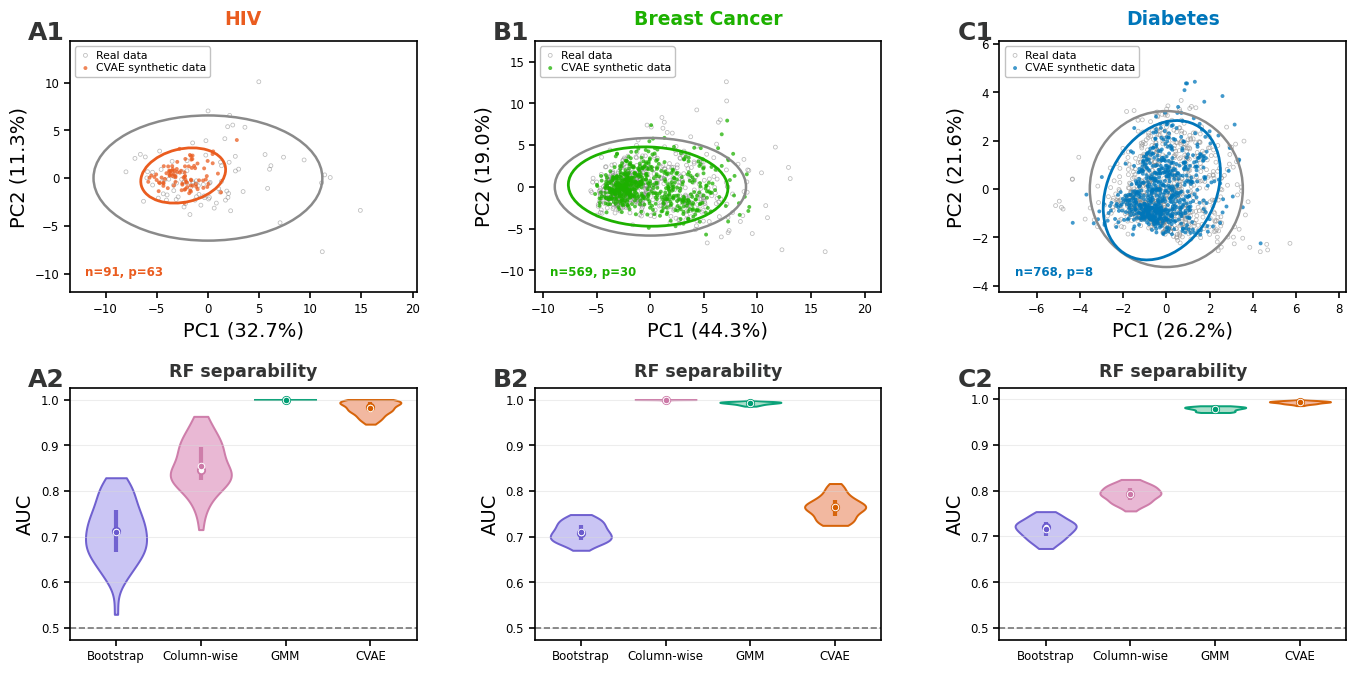

In [197]:
auc_runs = get_auc_runs(force=False)
fig2_6 = plot_figure2_six_panel(auc_runs)


## Figure 4: Synthetic Deviation from Real Conditional-Dependence Structure

Question: do synthetic datasets preserve the same conditional-dependency structure as the real dataset?

Figure 4 uses Graphical Lasso rather than ordinary pairwise correlation. Graphical Lasso estimates a sparse precision matrix, where off-diagonal entries encode conditional relationships among features:

`precision-matrix discrepancy = ||Theta_real - Theta_synthetic||_F`

Main readout:

- **A. Real HIV precision matrix**: off-diagonal real-data Graphical Lasso precision matrix after hierarchical feature ordering.
- **B. Closest synthetic precision matrix**: HIV synthetic method with the smallest Frobenius deviation from the real HIV precision matrix.
- **C. Most divergent synthetic precision matrix**: HIV synthetic method with the largest Frobenius deviation from the real HIV precision matrix.
- **D. Deviation from closest synthetic**: entrywise absolute deviation from the real HIV precision matrix.
- **E. Deviation from most divergent synthetic**: entrywise absolute deviation from the real HIV precision matrix.
- **F. Frobenius discrepancy**: all datasets and methods summarized quantitatively. Lower is better.

Panels A-C use one shared diverging precision scale, and Panels D-E use one shared sequential difference scale.

In [200]:
import importlib
import src.figure4_neighborhood as figure4_neighborhood

figure4_neighborhood = importlib.reload(figure4_neighborhood)

from src.figure4_neighborhood import (
    fit_glasso_precision,
    precision_to_partial_corr,
    get_edge_set,
    choose_anchor_feature,
    get_anchor_neighborhood_edges,
    plot_overlap_neighborhood,
    compute_edge_recovery,
    compute_synthetic_only_rate,
    compute_frobenius_deviation,
    plot_summary_metrics,
    plot_figure4_neighborhood_overlap,
    plot_figure4_edge_overlap_matrix,
    plot_figure4_edge_status_matrices,
    plot_supplemental_edge_status_matrices,
)



FIGURE4_ALPHAS = {"HIV": 0.504, "Breast Cancer": 0.502, "Diabetes": 0.0159}

def _build_notebook_precision_inputs(seed=SEED, cvae_epochs=CVAE_EPOCHS):
    real_data = {}
    synthetic_data = {}
    feature_name_map = {}
    for ds in DATASET_ORDER:
        data = datasets[ds]
        real_data[ds] = np.asarray(data["X"], dtype=np.float64)
        feature_name_map[ds] = list(data.get("feature_names", [f"f{i}" for i in range(real_data[ds].shape[1])]))
        synthetic_data[ds] = {}
        for method in METHOD_ORDER:
            X_syn, _ = sample_synthetic(ds, data, method, seed=seed, cvae_epochs=cvae_epochs)
            synthetic_data[ds][method] = np.asarray(X_syn, dtype=np.float64)
    return real_data, synthetic_data, feature_name_map


def plot_figure4_correlation_change(corr_summary=None, exemplar_ds="HIV", anchor_feature=None, threshold=1e-7):
    real_data, synthetic_data, feature_name_map = _build_notebook_precision_inputs(
        seed=SEED, cvae_epochs=CVAE_EPOCHS
    )
    return plot_figure4_edge_status_matrices(
        real_data=real_data,
        synthetic_data=synthetic_data,
        feature_names=feature_name_map,
        alphas=FIGURE4_ALPHAS,
        dataset_order=DATASET_ORDER,
        method_order=METHOD_ORDER,
        exemplar_ds=exemplar_ds,
        threshold=threshold,
    )


Epoch    1 | train loss=59.4345 recon=59.3622 kl=0.1446 | val loss=78.4132 recon=78.3381 kl=0.1501
Epoch   10 | train loss=55.0814 recon=54.5651 kl=1.0327 | val loss=75.1556 recon=74.4211 kl=1.4690
Epoch   20 | train loss=49.5437 recon=46.3646 kl=6.3583 | val loss=59.7132 recon=57.2741 kl=4.8782
Epoch   30 | train loss=37.0336 recon=35.2526 kl=3.5620 | val loss=55.3492 recon=52.8178 kl=5.0628
Epoch   40 | train loss=35.7443 recon=31.5312 kl=8.4264 | val loss=53.4445 recon=48.9844 kl=8.9201
Epoch   50 | train loss=33.3516 recon=29.9936 kl=6.7162 | val loss=48.4559 recon=44.0604 kl=8.7910
Epoch   60 | train loss=33.5782 recon=29.7126 kl=7.7312 | val loss=47.5115 recon=43.3358 kl=8.3514
Epoch   70 | train loss=25.4368 recon=21.6556 kl=7.5625 | val loss=49.1987 recon=44.7192 kl=8.9590
Epoch   80 | train loss=27.3788 recon=22.9788 kl=8.8000 | val loss=46.1841 recon=41.4502 kl=9.4678
Epoch   90 | train loss=26.5942 recon=21.7606 kl=9.6673 | val loss=46.5686 recon=41.9486 kl=9.2398
Epoch  100

c:\Users\tonyt\Desktop\distinguishable_data\.venv\Lib\site-packages\sklearn\covariance\_graph_lasso.py:199: ConvergenceWarning: graphical_lasso: did not converge after 1000 iteration: dual gap: -1.299e-04
  warnings.warn(


,dataset,method,frobenius_deviation,edge_recovery,synthetic_only_rate,n_real_edges,n_synthetic_edges
4,Breast Cancer,Bootstrap,0.378561,0.927835,0.052632,97,95
7,Breast Cancer,CVAE,0.750652,0.948454,0.192982,97,114
5,Breast Cancer,Column-wise,2.412744,0.278351,0.100000,97,30
6,Breast Cancer,GMM,0.922085,0.793814,0.012821,97,78
8,Diabetes,Bootstrap,0.370135,1.000000,0.125000,21,24
11,Diabetes,CVAE,2.851276,0.952381,0.200000,21,25
9,Diabetes,Column-wise,1.662236,0.666667,0.263158,21,19
10,Diabetes,GMM,0.283061,0.952381,0.200000,21,25
0,HIV,Bootstrap,1.183656,0.811828,0.209424,186,191
3,HIV,CVAE,2.508329,0.741935,0.588060,186,335


,matrix_index,feature_original_index,feature_name
0,1,1,spikeProduction_D1D2
1,2,2,spikeDecay_D1D2
2,3,51,V8_IL2
3,4,52,V9_IL2
4,5,56,Il2_production
...,...,...,...
58,59,8,RBDDecay_D3
59,60,3,spikeProduction_D3
60,61,4,spikeDecay_D3
61,62,5,RBDProduction_D1D2


Saved Figure 4 to c:\Users\tonyt\Desktop\distinguishable_data\data_synthesis\notebooks\revision_exports\figure_4_edge_status_matrices.png


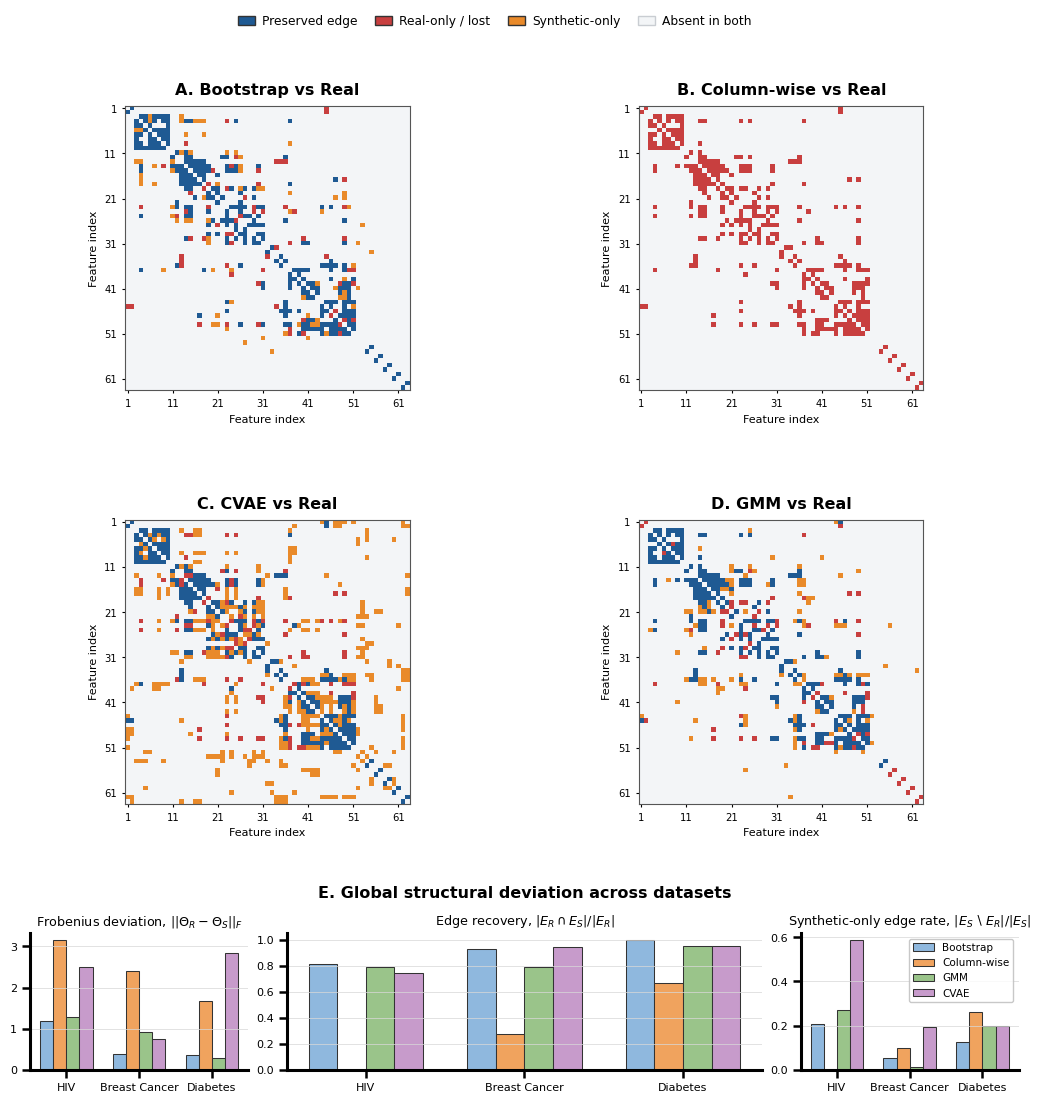

In [201]:
fig4_result = plot_figure4_correlation_change()
corr_summary = fig4_result.metrics

display(corr_summary.sort_values(["dataset", "method"]))
display(fig4_result.feature_index)


## Figure 4 Supplementary Edge-Status Matrices

Epoch    1 | train loss=59.4345 recon=59.3622 kl=0.1446 | val loss=78.4132 recon=78.3381 kl=0.1501
Epoch   10 | train loss=55.0814 recon=54.5651 kl=1.0327 | val loss=75.1556 recon=74.4211 kl=1.4690
Epoch   20 | train loss=49.5437 recon=46.3646 kl=6.3583 | val loss=59.7132 recon=57.2741 kl=4.8782
Epoch   30 | train loss=37.0336 recon=35.2526 kl=3.5620 | val loss=55.3492 recon=52.8178 kl=5.0628
Epoch   40 | train loss=35.7443 recon=31.5312 kl=8.4264 | val loss=53.4445 recon=48.9844 kl=8.9201
Epoch   50 | train loss=33.3516 recon=29.9936 kl=6.7162 | val loss=48.4559 recon=44.0604 kl=8.7910
Epoch   60 | train loss=33.5782 recon=29.7126 kl=7.7312 | val loss=47.5115 recon=43.3358 kl=8.3514
Epoch   70 | train loss=25.4368 recon=21.6556 kl=7.5625 | val loss=49.1987 recon=44.7192 kl=8.9590
Epoch   80 | train loss=27.3788 recon=22.9788 kl=8.8000 | val loss=46.1841 recon=41.4502 kl=9.4678
Epoch   90 | train loss=26.5942 recon=21.7606 kl=9.6673 | val loss=46.5686 recon=41.9486 kl=9.2398
Epoch  100

c:\Users\tonyt\Desktop\distinguishable_data\.venv\Lib\site-packages\sklearn\covariance\_graph_lasso.py:199: ConvergenceWarning: graphical_lasso: did not converge after 1000 iteration: dual gap: -1.299e-04
  warnings.warn(
c:\Users\tonyt\Desktop\distinguishable_data\.venv\Lib\site-packages\sklearn\covariance\_graph_lasso.py:199: ConvergenceWarning: graphical_lasso: did not converge after 1000 iteration: dual gap: -1.299e-04
  warnings.warn(


Saved Figure 4 supplements:
- Breast Cancer: c:\Users\tonyt\Desktop\distinguishable_data\data_synthesis\notebooks\revision_exports\supplemental_figure4_breast_cancer_edge_status_matrices.png
- Diabetes: c:\Users\tonyt\Desktop\distinguishable_data\data_synthesis\notebooks\revision_exports\supplemental_figure4_diabetes_edge_status_matrices.png


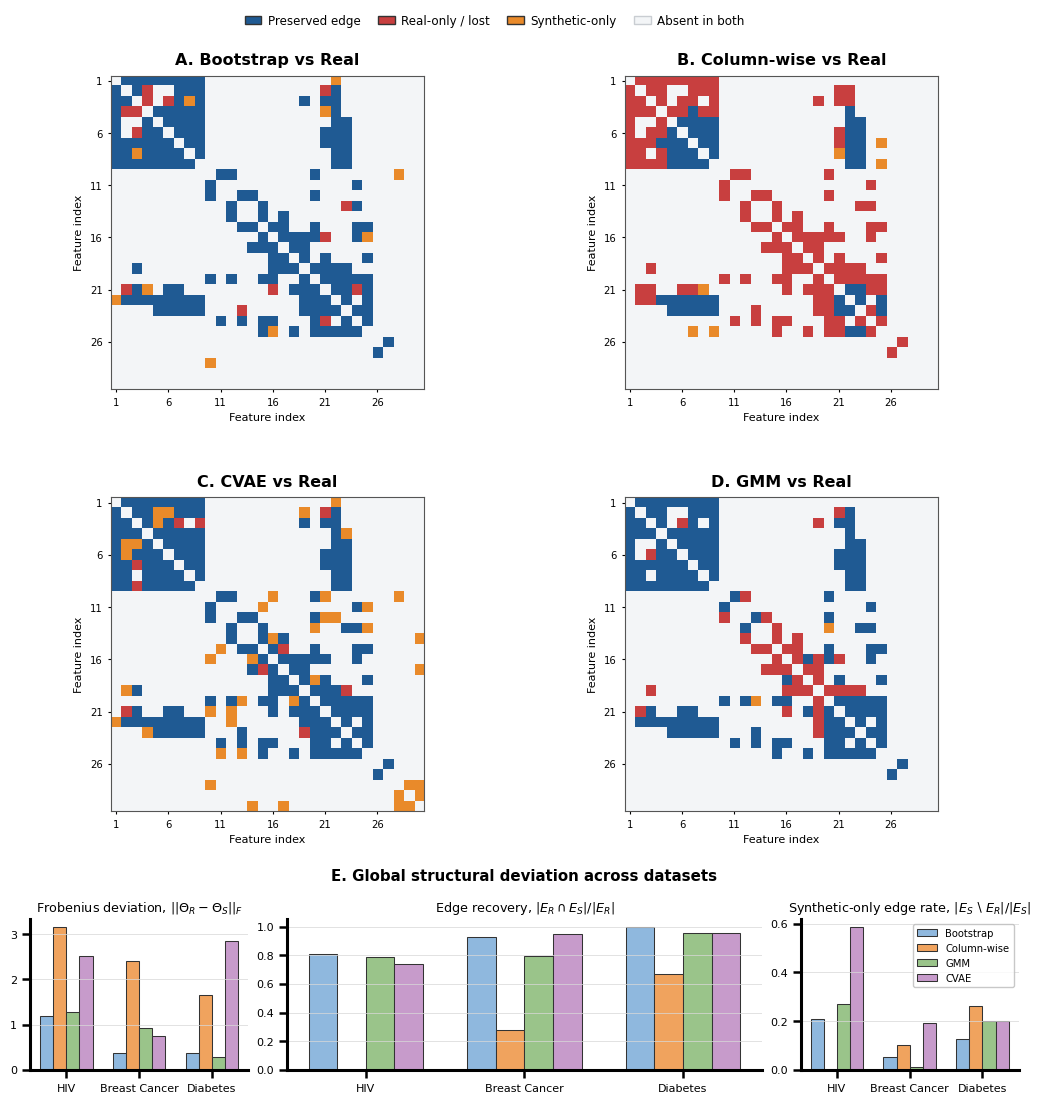

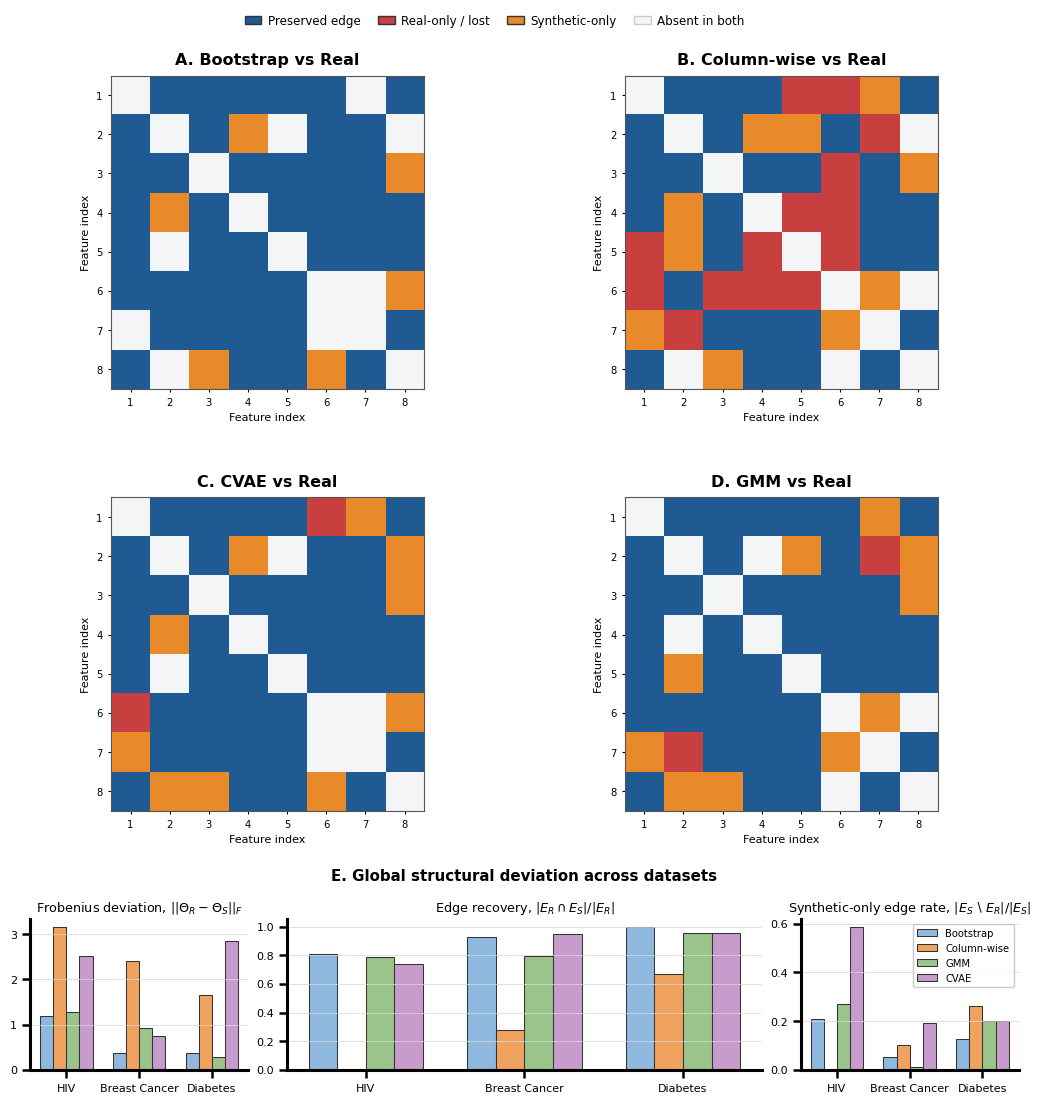

In [202]:
figure4_supp_real_data, figure4_supp_synthetic_data, figure4_supp_feature_names = _build_notebook_precision_inputs(
    seed=SEED, cvae_epochs=CVAE_EPOCHS
)


def plot_figure4_supplemental_edge_status(dataset_name, threshold=1e-7):
    result = plot_supplemental_edge_status_matrices(
        real_data=figure4_supp_real_data,
        synthetic_data=figure4_supp_synthetic_data,
        feature_names=figure4_supp_feature_names,
        alphas=FIGURE4_ALPHAS,
        dataset_order=DATASET_ORDER,
        method_order=METHOD_ORDER,
        exemplar_ds=dataset_name,
        threshold=threshold,
        save_path=FIGURE4_SUPPLEMENT_OUTPUTS[dataset_name],
    )

    # Paper assembly will add captions/titles, so keep the plotted figure title-free.
    if result.fig._suptitle is not None:
        result.fig._suptitle.set_text("")
    result.fig.subplots_adjust(top=0.885)
    return result


fig4_supp_breast = plot_figure4_supplemental_edge_status("Breast Cancer")
fig4_supp_diabetes = plot_figure4_supplemental_edge_status("Diabetes")

## Figure 5: Noise Sensitivity

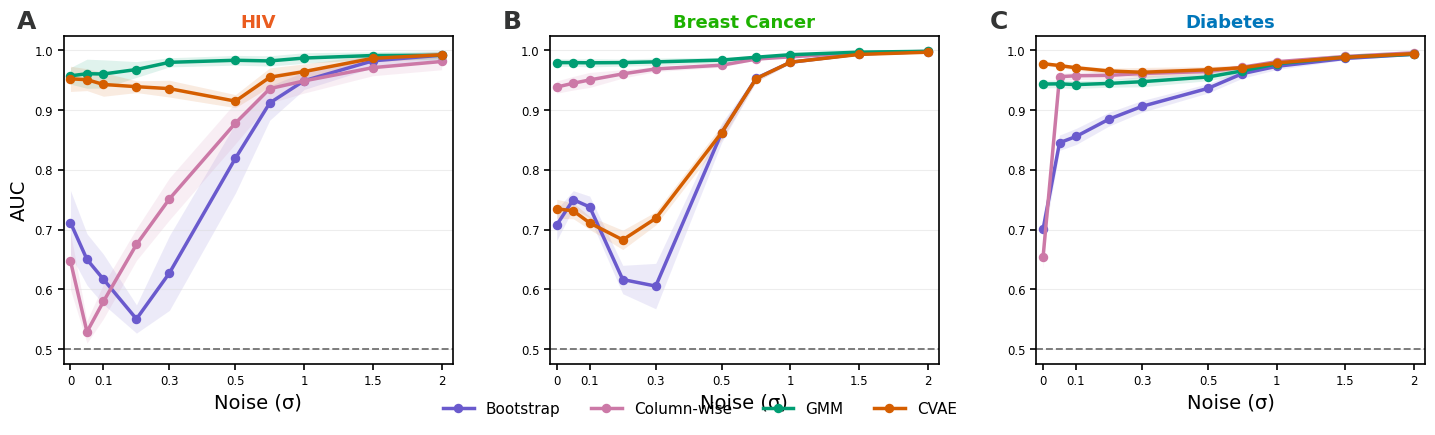

In [ ]:
def stratified_subsample(X, y, n0, n1, seed=SEED):
    rng = np.random.default_rng(seed)
    idx0 = np.where(y == 0)[0]
    idx1 = np.where(y == 1)[0]
    take0 = rng.choice(idx0, size=max(1, min(n0, len(idx0))), replace=False)
    take1 = rng.choice(idx1, size=max(1, min(n1, len(idx1))), replace=False)
    idx = np.r_[take0, take1]
    rng.shuffle(idx)
    return X[idx], y[idx]


def compute_noise_sensitivity(datasets, seed=SEED, repeats=NOISE_REPEATS, sigmas=PROBE_SIGMAS, frac=NOISE_FRAC, cvae_epochs=CVAE_EPOCHS):
    rows = []
    for ds in DATASET_ORDER:
        data = datasets[ds]
        X = np.asarray(data["X"], dtype=np.float32)
        y = np.asarray(data["y"], dtype=int)
        n0 = max(2, int((y == 0).sum() * frac))
        n1 = max(2, int((y == 1).sum() * frac))
        X_sub, y_sub = stratified_subsample(X, y, n0, n1, seed=seed)
        stds = X_sub.std(axis=0)
        stds = np.where(stds == 0, 1.0, stds)
        feat_cols = [f"f{i}" for i in range(X_sub.shape[1])]
        print(f"[noise] training CVAE for {ds}")
        state = train_cvae(X_sub, y_sub, cfg=Config(seed=seed, epochs=cvae_epochs, batch_size=32), verbose=False)
        generators = {
            "Bootstrap": lambda s: sample_bootstrap(X_sub, y_sub, n0, n1, seed=s),
            "Column-wise": lambda s: sample_columnwise(X_sub, y_sub, n0, n1, seed=s),
            "GMM": lambda s: sample_gmm(X_sub, y_sub, n0, n1, seed=s),
            "CVAE": lambda s: sample_trained_cvae(state, n0, n1, seed=s),
        }
        for method, gen in generators.items():
            for sigma in sigmas:
                vals = []
                for r in range(repeats):
                    rep_seed = seed + r
                    X_syn, _ = gen(rep_seed)
                    X_syn = np.asarray(X_syn, dtype=np.float64)
                    if sigma > 0:
                        rng = np.random.default_rng(rep_seed + 500)
                        X_syn = X_syn + rng.standard_normal(X_syn.shape) * stds * sigma
                    real_df = pd.DataFrame(X_sub, columns=feat_cols)
                    real_df["target"] = 1
                    syn_df = pd.DataFrame(X_syn, columns=feat_cols)
                    syn_df["target"] = 0
                    combined = pd.concat([real_df, syn_df], ignore_index=True)
                    avg, _, _ = RFWrapper.from_combined(combined)
                    vals.append(max(float(avg), 1.0 - float(avg)))
                rows.append({"dataset": ds, "method": method, "sigma": sigma,
                             "sep_mean": float(np.mean(vals)), "sep_sd": float(np.std(vals)),
                             "sep_values": [float(v) for v in vals]})
                print(f"[noise] {ds} {method} sigma={sigma}")
    return pd.DataFrame(rows)


def get_noise_sensitivity(force=False):
    cached = None if force else _read_cache("noise_df")
    if cached is not None:
        return cached
    result = compute_noise_sensitivity(datasets)
    return _write_cache("noise_df", result)


def noise_axis_position(sigma, expand_until=0.5, expand_factor=2.4):
    sigma = np.asarray(sigma, dtype=float)
    return np.where(sigma <= expand_until, sigma * expand_factor, expand_until * expand_factor + (sigma - expand_until))


def plot_figure5_noise(noise_df):
    fig, axes = plt.subplots(1, 3, figsize=(14.8, 4.9), sharey=True, constrained_layout=False)
    legend_handles = []
    tick_sigmas = np.asarray(sorted(noise_df["sigma"].unique()), dtype=float)
    tick_sigmas = tick_sigmas[np.isin(tick_sigmas, [0, 0.1, 0.3, 0.5, 1.0, 1.5, 2.0])]
    tick_positions = noise_axis_position(tick_sigmas)
    tick_labels = [f"{s:g}" for s in tick_sigmas]

    for ax, ds, panel in zip(axes, DATASET_ORDER, ["A", "B", "C"]):
        sub = noise_df[noise_df["dataset"] == ds]
        for method in METHOD_ORDER:
            m = sub[sub["method"] == method].sort_values("sigma")
            if m.empty:
                continue
            x = noise_axis_position(m["sigma"])
            line, = ax.plot(x, m["sep_mean"], marker="o", color=METHOD_COLORS[method], label=method,
                            linewidth=2.5, markersize=5.8)
            ax.fill_between(x, m["sep_mean"] - m["sep_sd"], m["sep_mean"] + m["sep_sd"],
                            color=METHOD_COLORS[method], alpha=0.12, linewidth=0)
            if ax is axes[0]:
                legend_handles.append(line)
        ax.axhline(0.5, color="#777777", linestyle="--", linewidth=1.35)

        ax.set_title(ds, color=DATASET_COLORS[ds], weight="semibold", fontsize=13)
        ax.set_xlabel("Noise (σ)")
        ax.set_xticks(tick_positions)
        ax.set_xticklabels(tick_labels)
        ax.set_xlim(noise_axis_position(0) - 0.05, noise_axis_position(float(np.max(noise_df["sigma"]))) + 0.08)
        clean_axis(ax, grid_axis="y")

        for spine in ax.spines.values():
            spine.set_visible(True)
            spine.set_linewidth(1.2)

        ax.tick_params(labelsize=8.5, width=1.2, length=4, labelleft=True)

        add_panel_label(ax, panel)
    axes[0].set_ylabel("AUC")
    fig.legend(legend_handles, METHOD_ORDER, loc="lower center", bbox_to_anchor=(0.5, 0.01), ncol=len(METHOD_ORDER),
               frameon=True, facecolor="white", edgecolor="black", framealpha=0, borderpad=0.55)
    # fig.suptitle("Noise sensitivity", y=0.98, fontsize=15, weight="semibold")
    fig.subplots_adjust(left=0.07, right=0.99, top=0.82, bottom=0.2, wspace=0.25)
    return fig


noise_df = get_noise_sensitivity(force=False)
fig5_noise = plot_figure5_noise(noise_df)


## Figure 6: Single Combined Reverse-Ablation Figure

This uses the all-dataset A-C function added to the outline notebook, and keeps the x-axis as percentage of top discriminator-ranked features removed so datasets with different numbers of features are comparable.


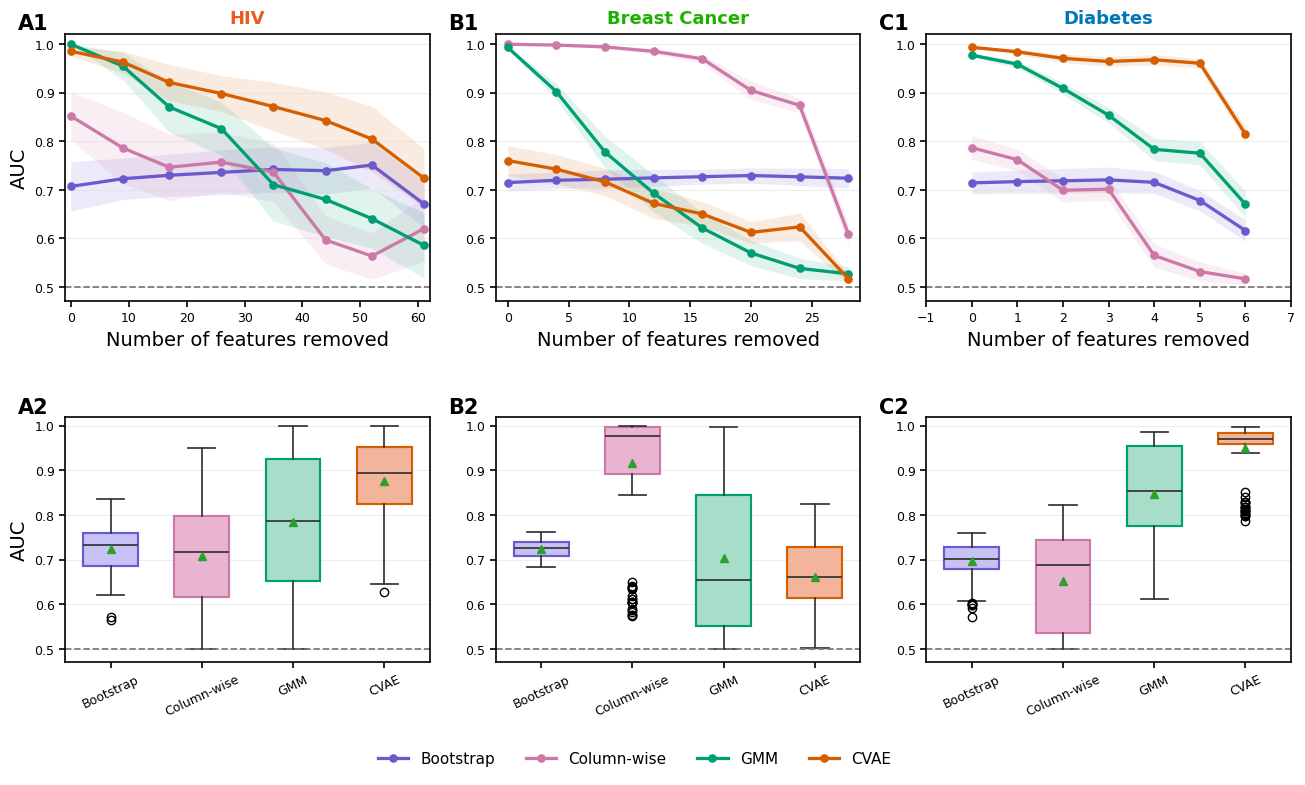

In [204]:
def _flat_values(series):
    vals = []
    for item in series:
        vals.extend(item if isinstance(item, (list, tuple, np.ndarray)) else [item])
    return np.asarray(vals, dtype=float)


def plot_figure6_ablation_all_datasets(ablation_df):
    fig = plt.figure(figsize=(13.4, 8.6), constrained_layout=False)
    gs = fig.add_gridspec(
        2, len(DATASET_ORDER),
        height_ratios=[1.25, 1.15]
    )
    curve_axes = [fig.add_subplot(gs[0, i]) for i in range(len(DATASET_ORDER))]
    box_axes = [fig.add_subplot(gs[1, i], sharey=curve_axes[0]) for i in range(len(DATASET_ORDER))]

    legend_handles = []
    for panel_idx, (ax_curve, ax_box, ds) in enumerate(zip(curve_axes, box_axes, DATASET_ORDER)):
        sub = ablation_df[ablation_df["dataset"] == ds]
        box_values, box_labels = [], []
        if sub.empty:
            ax_curve.set_visible(False)
            ax_box.set_visible(False)
            continue

        for method in METHOD_ORDER:
            m = sub[sub["method"] == method].sort_values("n_features_removed")
            if m.empty:
                continue
            n_removed = m["n_features_removed"]
            line, = ax_curve.plot(n_removed, m["auc_mean"], color=METHOD_COLORS[method], marker="o",  linewidth=2.35, markersize=5.2, label=method)
            ax_curve.fill_between(n_removed, m["auc_mean"] - m["auc_sd"], m["auc_mean"] + m["auc_sd"], color=METHOD_COLORS[method], alpha=0.12, linewidth=0)
            if panel_idx == 0:
                legend_handles.append(line)
            box_values.append(_flat_values(m["auc_values"]))
            box_labels.append(method)

        ax_curve.axhline(0.5, color="#777777", linestyle="--", linewidth=1.25)
        ax_curve.set_title(ds, color=DATASET_COLORS[ds], weight="semibold", pad=8, fontsize=13)
        col_letter = chr(ord("A") + panel_idx)

        ax_curve.text(
            -0.13, 1.08, f"{col_letter}1",
            transform=ax_curve.transAxes,
            fontsize=15,
            weight="bold",
            va="top",
            ha="left"
        )
        max_removed = int(sub["n_features_removed"].max())
        ax_curve.set_xlim(-1, max_removed + 1)
        ax_curve.set_xlabel("Number of features removed")
        clean_axis(ax_curve, grid_axis="y")

        for spine in ax_curve.spines.values():
            spine.set_visible(True)
            spine.set_linewidth(1.2)

        ax_curve.tick_params(labelsize=9.0, width=1.2, length=4)

        bp = ax_box.boxplot(box_values, tick_labels=box_labels, patch_artist=True, showmeans=True, widths=0.60)
        for patch, method in zip(bp["boxes"], box_labels):
            patch.set_facecolor(METHOD_PASTELS[method])
            patch.set_edgecolor(METHOD_COLORS[method])
            patch.set_linewidth(1.55)
        for key in ["whiskers", "caps", "medians", "means"]:
            for artist in bp.get(key, []):
                artist.set_color(NEUTRAL)
                artist.set_linewidth(1.25)
        ax_box.axhline(0.5, color="#777777", linestyle="--", linewidth=1.25)
        ax_box.tick_params(axis="x", rotation=25, labelsize=9.0, width=1.4, length=5)
        ax_box.text(
            -0.13, 1.08, f"{col_letter}2",
            transform=ax_box.transAxes,
            fontsize=15,
            weight="bold",
            va="top",
            ha="left"
        )


        clean_axis(ax_box, grid_axis="y")

        for spine in ax_box.spines.values():
            spine.set_visible(True)
            spine.set_linewidth(1.2)

        ax_box.tick_params(labelsize=9.0, width=1.2, length=4)
    curve_axes[0].set_ylabel("AUC")
    box_axes[0].set_ylabel("AUC")
    for ax in curve_axes[1:] + box_axes[1:]:
        ax.set_ylabel("") 
        ax.tick_params(labelleft=True) 

    y_values = []
    for _, row in ablation_df.iterrows():
        y_values.extend([row["auc_mean"] - row["auc_sd"], row["auc_mean"] + row["auc_sd"]])
        y_values.extend(row.get("auc_values", []))
    y_min = max(0.45, np.nanmin(y_values) - 0.03)
    y_max = min(1.02, np.nanmax(y_values) + 0.03)
    for ax in curve_axes + box_axes:
        if ax.get_visible():
            ax.set_ylim(y_min, y_max)

    handles = legend_handles[:len(METHOD_ORDER)]
    fig.legend(handles, [h.get_label() for h in handles], loc="lower center",
               bbox_to_anchor=(0.5, 0.01), ncol=len(handles), frameon=True,
               facecolor="white", edgecolor="black", framealpha=0, borderpad=0.55)
    # fig.suptitle("Reverse feature ablation", y=0.98, fontsize=15, weight="semibold")

    fig.subplots_adjust(left=0.075, right=0.99, top=0.88, bottom=0.15, wspace=0.18, hspace=0.45)
    return fig


ablation_df = get_reverse_ablation(force=False)
fig6_ac = plot_figure6_ablation_all_datasets(ablation_df)


## Export Helpers

Exports are intentionally explicit so we do not overwrite manuscript files by accident.


In [205]:
EXPORT_DIR = repo_root / "data_synthesis" / "notebooks" / "revision_exports"
EXPORT_DIR.mkdir(parents=True, exist_ok=True)

# Uncomment after running the corresponding figure cells.
# fig2_6.savefig(EXPORT_DIR / "figure2_six_panel_revision.png", dpi=300, bbox_inches="tight")
# fig2_9.savefig(EXPORT_DIR / "figure2_nine_panel_revision.png", dpi=300, bbox_inches="tight")
# fig4_result.fig.savefig(EXPORT_DIR / "figure_4_edge_status_matrices.png", dpi=300, bbox_inches="tight")
# fig5_noise.savefig(EXPORT_DIR / "figure5_noise_revision.png", dpi=300, bbox_inches="tight")
# fig6_ac.savefig(EXPORT_DIR / "figure6_ablation_all_datasets_revision.png", dpi=300, bbox_inches="tight")